In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
df = pd.read_csv(
    r'C:\Users\M.Hasini\OneDrive\Desktop\ML\SalesForecastingProject\data\Sample - Superstore.csv',
    encoding='latin1'
)

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [13]:
df.dropna(inplace=True)

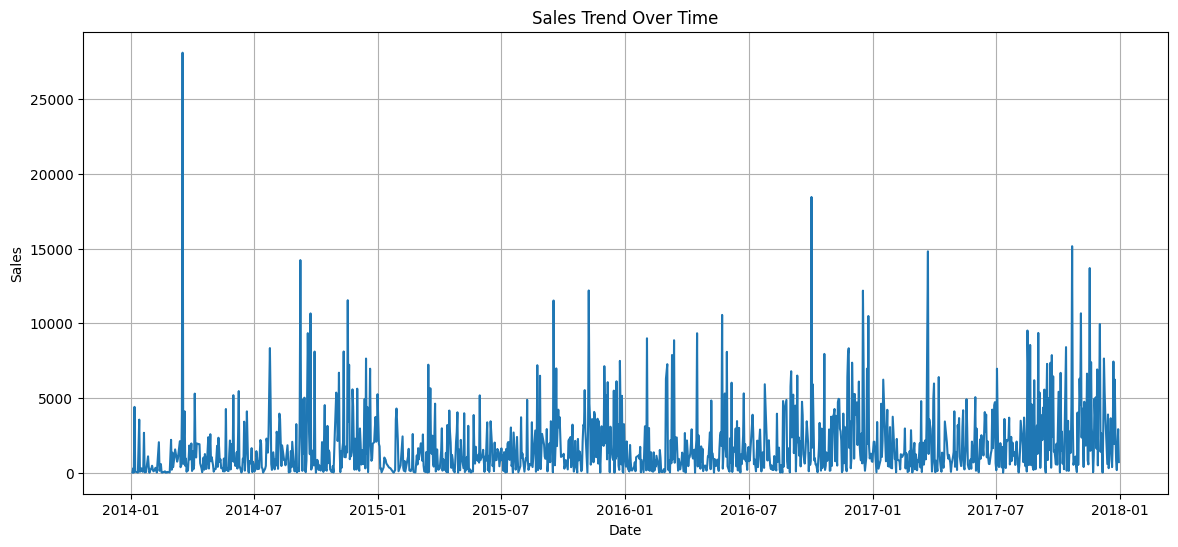

MAE: 312.14278488536473


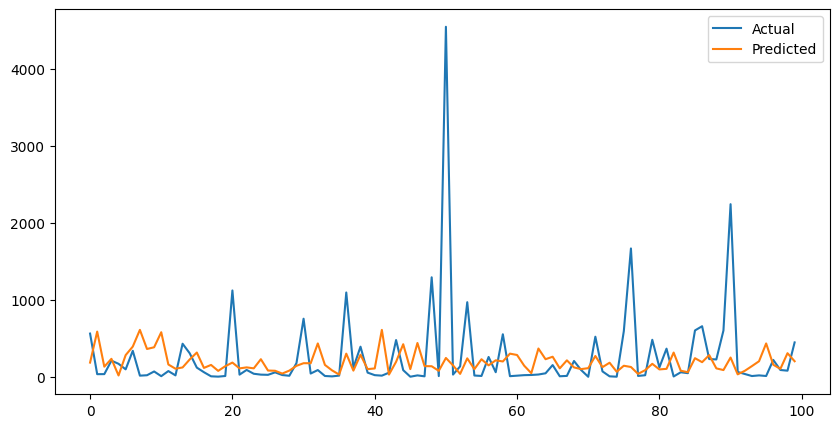

In [28]:
df.columns = df.columns.str.strip()

df['Order Date'] = pd.to_datetime(df['Order Date'])

df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month
df['day'] = df['Order Date'].dt.day

df.head()
sales_data = df.groupby('Order Date')['Sales'].sum().reset_index()
plt.figure(figsize=(14,6))

plt.plot(sales_data['Order Date'], sales_data['Sales'])

plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.grid(True)

plt.show()
X = df[['year', 'month', 'day']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = RandomForestRegressor()

model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')

plt.legend()
plt.show()

In [29]:
future = pd.DataFrame({
    'year':[2026],
    'month':[6],
    'day':[1]
})

future_prediction = model.predict(future)

print("Predicted Sales:", future_prediction)

Predicted Sales: [611.9853722]


1. Sales show seasonal trends.
2. Forecasting helps inventory planning.
3. Businesses can prepare staff during high demand.
4. Forecast reduces losses due to overstocking.